# Вычисление интеграла методом Монте-Карло

Задача: вычислить интеграл

$$
I = \int_{1}^{3}\ln(x)\,dx
$$

методом Монте-Карло, используя **2000 случайных точек** на отрезке \([1;3]\).  
Дополнительно нужно оценить погрешность, построить доверительный интервал и график сходимости.


## Идея метода

Если случайная величина \(X\) равномерно распределена на отрезке \([a;b]\), то

$$
\int_a^b f(x)\,dx = (b-a)\,\mathbb{E}[f(X)].
$$

Значит, интеграл можно приблизить так:

$$
I_N \approx (b-a)\cdot \frac{1}{N}\sum_{i=1}^{N} f(x_i),
$$

где \(x_i\) — случайные точки из равномерного распределения на \([1;3]\), а \(f(x)=\ln(x)\).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Параметры задачи
a = 1
b = 3
N = 2000
seed = 42  # фиксируем seed, чтобы результат можно было воспроизвести

rng = np.random.default_rng(seed)

# Генерируем 2000 случайных точек на [1; 3]
x = rng.uniform(a, b, N)

# Значения функции ln(x)
f_x = np.log(x)

# Оценка интеграла методом Монте-Карло
mc_integral = (b - a) * np.mean(f_x)

# Точное значение интеграла для проверки:
# ∫ ln(x) dx = x ln(x) - x
exact_integral = b * math.log(b) - b - (a * math.log(a) - a)

mc_integral, exact_integral


(np.float64(1.3011578316622567), 1.2958368660043291)

In [2]:
# Оценка погрешности
absolute_error = abs(mc_integral - exact_integral)
relative_error = absolute_error / abs(exact_integral)

# Стандартная ошибка оценки интеграла
sample_std = np.std(f_x, ddof=1)
standard_error = (b - a) * sample_std / np.sqrt(N)

# 95% доверительный интервал:
# для N=2000 нормальное приближение подходит хорошо, поэтому берем z ≈ 1.96
z = 1.96
ci_lower = mc_integral - z * standard_error
ci_upper = mc_integral + z * standard_error

print(f"Оценка Монте-Карло: {mc_integral:.6f}")
print(f"Точное значение: {exact_integral:.6f}")
print(f"Абсолютная погрешность: {absolute_error:.6f}")
print(f"Относительная погрешность: {relative_error:.4%}")
print(f"Стандартная ошибка: {standard_error:.6f}")
print(f"95% доверительный интервал: [{ci_lower:.6f}; {ci_upper:.6f}]")


Оценка Монте-Карло: 1.301158
Точное значение: 1.295837
Абсолютная погрешность: 0.005321
Относительная погрешность: 0.4106%
Стандартная ошибка: 0.013788
95% доверительный интервал: [1.274134; 1.328182]


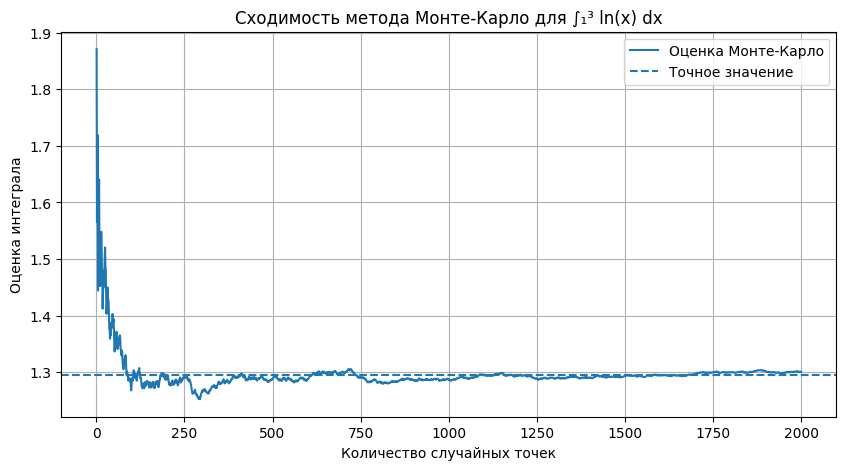

In [3]:
# График сходимости
running_estimates = (b - a) * np.cumsum(f_x) / np.arange(1, N + 1)

plt.figure(figsize=(10, 5))
plt.plot(np.arange(1, N + 1), running_estimates, label="Оценка Монте-Карло")
plt.axhline(exact_integral, linestyle="--", label="Точное значение")
plt.xlabel("Количество случайных точек")
plt.ylabel("Оценка интеграла")
plt.title("Сходимость метода Монте-Карло для ∫₁³ ln(x) dx")
plt.legend()
plt.grid(True)
plt.show()


## Вывод

Полученная оценка интеграла близка к точному значению \(3\ln 3 - 2\).  
Из-за случайного выбора точек результат не совпадает с точным значением идеально, но абсолютная погрешность мала.

Доверительный интервал показывает диапазон, в который с вероятностью около 95% попадает истинное значение интеграла при таком количестве случайных точек.  
На графике видно, что при увеличении числа точек оценка постепенно стабилизируется около точного значения.
